In [3]:
import pandas as pd
employee_data=pd.read_csv(r"D:\Codings\Employee attrition\WA_Fn-UseC_-HR-Employee-Attrition.csv")
employee_data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
employee_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
employee_data.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [9]:
x = employee_data.copy()
y = x.pop('Attrition')

for column in x.select_dtypes("object"):
    x[column], _ = x[column].factorize()
    

In [11]:
x.shape

(1470, 34)

In [13]:
x.head()


,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,0,1102,0,1,2,0,1,1,2,...,1,80,0,8,0,1,6,4,0,5
1,49,1,279,1,8,1,0,1,2,3,...,4,80,1,10,3,3,10,7,1,7
2,37,0,1373,1,2,2,1,1,4,4,...,2,80,0,7,3,3,0,0,0,0
3,33,1,1392,1,3,4,0,1,5,4,...,3,80,0,8,3,3,8,7,3,0
4,27,0,591,1,2,1,2,1,7,1,...,4,80,1,6,3,3,2,2,2,2


In [15]:
y.value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [17]:
from sklearn.feature_selection import mutual_info_classif
mi_scores=mutual_info_classif(x,y,discrete_features='auto')
mi_scores=pd.Series(mi_scores,name="MiScores",index=x.columns)
mi_scores=mi_scores.sort_values(ascending=False)
mi_scores

JobRole                     0.043858
Age                         0.036851
OverTime                    0.035776
MonthlyIncome               0.032776
MaritalStatus               0.030371
YearsInCurrentRole          0.029494
JobLevel                    0.021466
StockOptionLevel            0.021164
PercentSalaryHike           0.020899
YearsAtCompany              0.020758
EnvironmentSatisfaction     0.017210
YearsWithCurrManager        0.013606
TotalWorkingYears           0.013538
JobSatisfaction             0.012047
DistanceFromHome            0.011530
YearsSinceLastPromotion     0.011037
NumCompaniesWorked          0.010965
WorkLifeBalance             0.009425
EmployeeCount               0.008571
EmployeeNumber              0.008003
TrainingTimesLastYear       0.007362
DailyRate                   0.005978
Over18                      0.005190
Gender                      0.002880
RelationshipSatisfaction    0.002573
PerformanceRating           0.002546
MonthlyRate                 0.002512
S

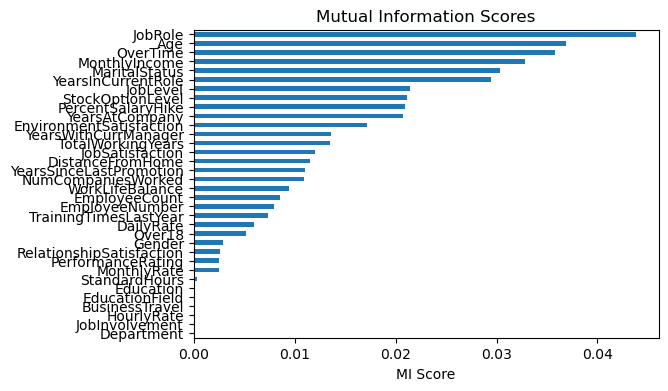

In [19]:
import seaborn as sns 
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
mi_scores.sort_values().plot(kind="barh")
plt.title("Mutual Information Scores")
plt.xlabel("MI Score")
plt.show()

In [20]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(random_state=42)
rf.fit(x,y)
importance = pd.Series(
    rf.feature_importances_,
    index=x.columns
)
importance = importance.sort_values(ascending=False)
print(importance)

MonthlyIncome               0.069342
Age                         0.054983
OverTime                    0.053742
DailyRate                   0.053535
TotalWorkingYears           0.051735
HourlyRate                  0.050122
EmployeeNumber              0.049045
DistanceFromHome            0.046702
MonthlyRate                 0.046308
YearsAtCompany              0.041314
NumCompaniesWorked          0.032954
PercentSalaryHike           0.031949
YearsWithCurrManager        0.030068
JobRole                     0.029747
EnvironmentSatisfaction     0.028556
JobSatisfaction             0.027672
StockOptionLevel            0.027342
WorkLifeBalance             0.026302
YearsInCurrentRole          0.025598
EducationField              0.025589
TrainingTimesLastYear       0.024834
JobInvolvement              0.024784
YearsSinceLastPromotion     0.024184
RelationshipSatisfaction    0.022312
JobLevel                    0.021372
MaritalStatus               0.020815
Education                   0.018701
B

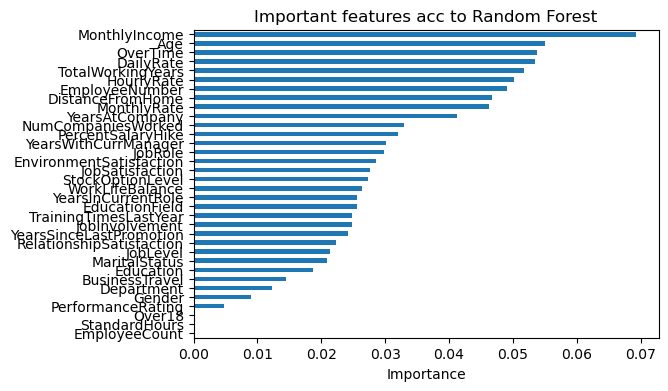

In [21]:
plt.figure(figsize=(6,4))
importance.sort_values().plot(kind="barh")
plt.title("Important features acc to Random Forest")
plt.xlabel("Importance")
plt.show()

In [22]:
cols_to_drop = [
    "EmployeeNumber",
    "EmployeeCount",
    "Over18",
    "StandardHours"
]
employee_data=employee_data.drop(columns=cols_to_drop)

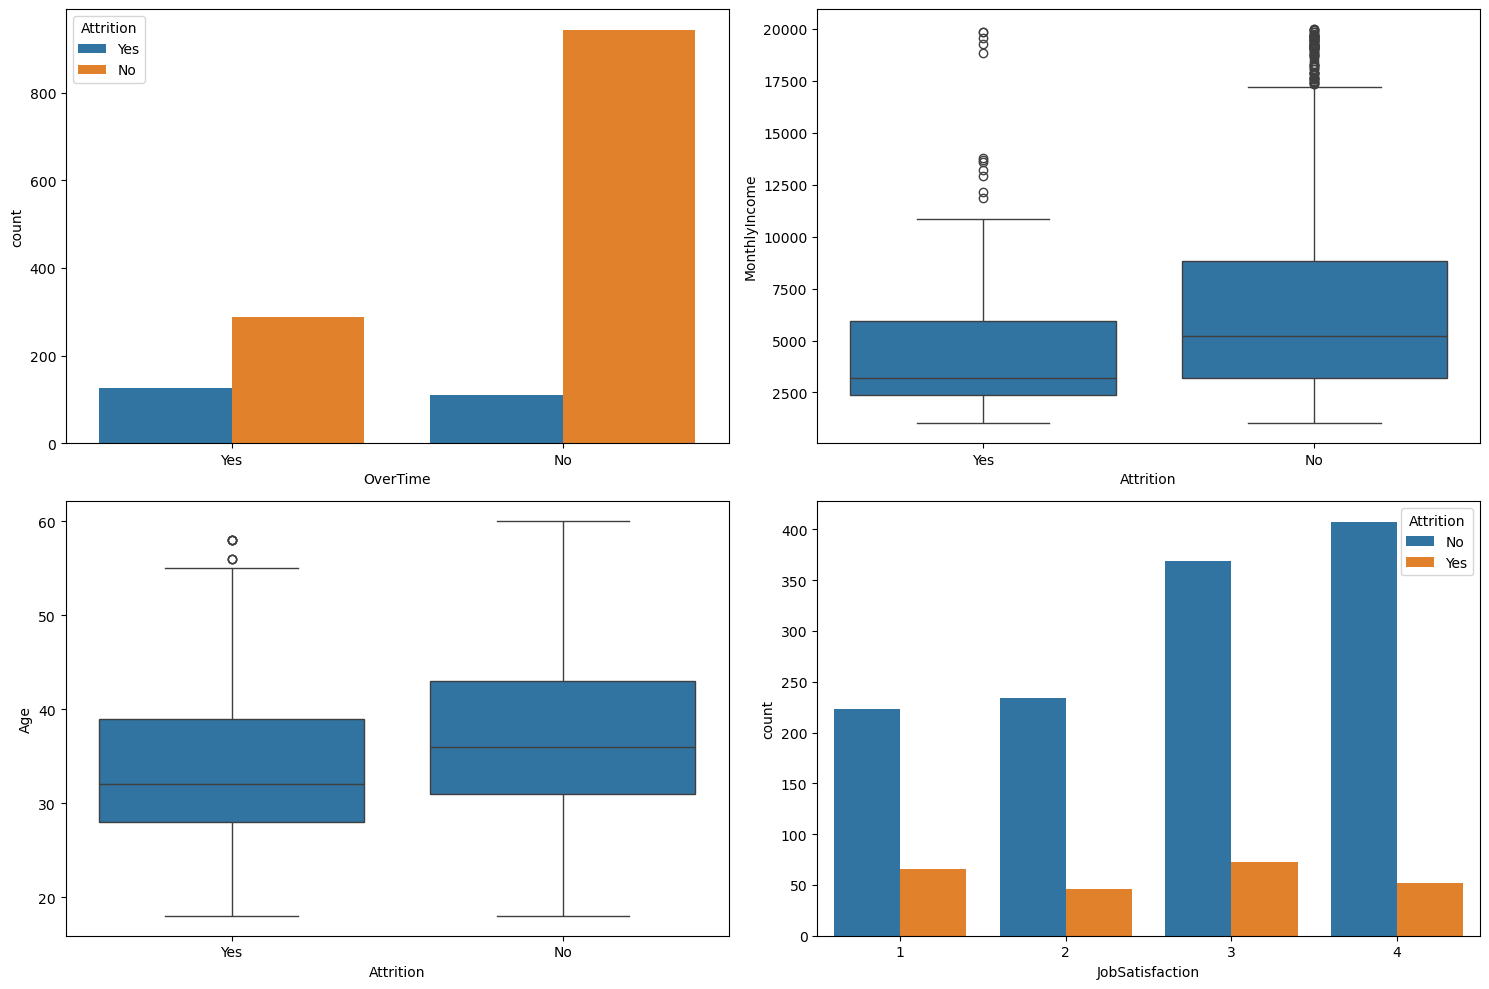

In [41]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(15,10)
)

sns.countplot(
    x="OverTime",
    hue="Attrition",
    data=employee_data,
    ax=axes[0,0]
)

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=employee_data,
    ax=axes[0,1]
)

sns.boxplot(
    x="Attrition",
    y="Age",
    data=employee_data,
    ax=axes[1,0]
)

sns.countplot(
    x="JobSatisfaction",
    hue="Attrition",
    data=employee_data,
    ax=axes[1,1]
)

plt.tight_layout()
plt.show()

In [39]:
X=employee_data.drop("Attrition",axis=1)
y=employee_data["Attrition"]
y=y.map({
    "No":0,
    "Yes":1   
})
X=pd.get_dummies(
    X,
    drop_first=True
)

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

log_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=42))
])

log_pipeline.fit(X_train, y_train)

log_preds = log_pipeline.predict(X_test)
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, log_preds))
print("Precision:", precision_score(y_test, log_preds))
print("Recall:", recall_score(y_test, log_preds))
print("F1 Score:", f1_score(y_test, log_preds))

Logistic Regression Results
Accuracy: 0.8605442176870748
Precision: 0.6153846153846154
Recall: 0.3404255319148936
F1 Score: 0.4383561643835616


In [45]:
print(classification_report(y_test, log_preds))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



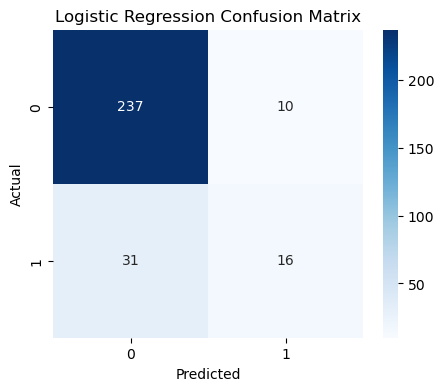

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, log_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [49]:
dectree_pipeline = Pipeline([
    ("model", DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

dectree_pipeline.fit(X_train, y_train)

dectree_preds = dectree_pipeline.predict(X_test)
print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, dectree_preds))
print("Precision:", precision_score(y_test, dectree_preds))
print("Recall:", recall_score(y_test, dectree_preds))
print("F1 Score:", f1_score(y_test, dectree_preds))




Decision Tree Results
Accuracy: 0.8367346938775511
Precision: 0.47368421052631576
Recall: 0.19148936170212766
F1 Score: 0.2727272727272727


In [51]:
print("\nClassification Report:")
print(classification_report(y_test, dectree_preds))


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       247
           1       0.47      0.19      0.27        47

    accuracy                           0.84       294
   macro avg       0.67      0.58      0.59       294
weighted avg       0.80      0.84      0.81       294



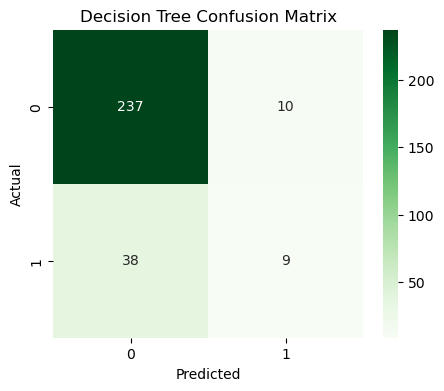

In [53]:
cm = confusion_matrix(y_test, dectree_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [55]:
rfc_pipeline=Pipeline([
    ("model",RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42     
    ))
])
rfc_pipeline.fit(X_train,y_train)
rfc_preds=rfc_pipeline.predict(X_test)
print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, rfc_preds))
print("Precision:", precision_score(y_test, rfc_preds))
print("Recall:", recall_score(y_test, rfc_preds))
print("F1 Score:", f1_score(y_test, rfc_preds))



Random Forest Results
Accuracy: 0.8299319727891157
Precision: 0.45454545454545453
Recall: 0.3191489361702128
F1 Score: 0.375


In [64]:
print("\nClassification Report:")
print(classification_report(y_test, dectree_preds))


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       247
           1       0.47      0.19      0.27        47

    accuracy                           0.84       294
   macro avg       0.67      0.58      0.59       294
weighted avg       0.80      0.84      0.81       294



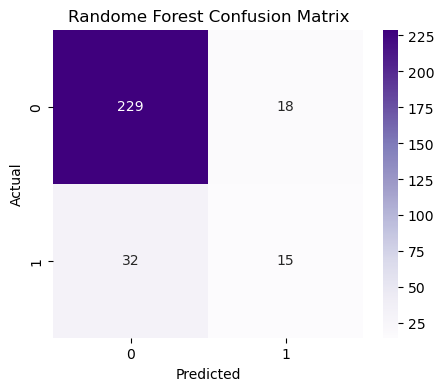

In [61]:
cm = confusion_matrix(y_test, rfc_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.title("Randome Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show() 

In [65]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [5, 8, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rfc_pipeline,
    param_grid=param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best Recall Score:")
print(grid_search.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters:
{'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 100}
Best Recall Score:
0.46315789473684205


In [67]:
best_rfc_model = grid_search.best_estimator_

tuned_rfc_preds = best_rfc_model.predict(X_test)
print("Tuned Random Forest Results")
print("Accuracy:", accuracy_score(y_test, tuned_rfc_preds))
print("Precision:", precision_score(y_test, tuned_rfc_preds))
print("Recall:", recall_score(y_test, tuned_rfc_preds))
print("F1 Score:", f1_score(y_test, tuned_rfc_preds))

Tuned Random Forest Results
Accuracy: 0.8129251700680272
Precision: 0.4166666666666667
Recall: 0.425531914893617
F1 Score: 0.42105263157894735


In [69]:
print("\nClassification Report:")
print(classification_report(y_test, tuned_rfc_preds))


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       247
           1       0.42      0.43      0.42        47

    accuracy                           0.81       294
   macro avg       0.65      0.66      0.65       294
weighted avg       0.81      0.81      0.81       294



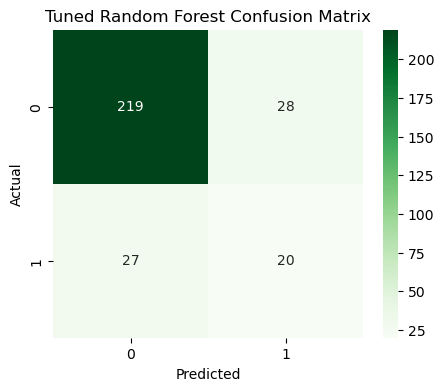

In [71]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

tuned_rfc_cm = confusion_matrix(y_test, tuned_rfc_preds)

plt.figure(figsize=(5,4))
sns.heatmap(tuned_rfc_cm, annot=True, fmt="d", cmap="Greens")
plt.title("Tuned Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [73]:
comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "Tuned Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, rfc_preds),
        accuracy_score(y_test, tuned_rfc_preds)
    ],
    "Precision": [
        precision_score(y_test, rfc_preds),
        precision_score(y_test, tuned_rfc_preds)
    ],
    "Recall": [
        recall_score(y_test, rfc_preds),
        recall_score(y_test, tuned_rfc_preds)
    ],
    "F1 Score": [
        f1_score(y_test, rfc_preds),
        f1_score(y_test, tuned_rfc_preds)
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.829932,0.454545,0.319149,0.375000
1,Tuned Random Forest,0.812925,0.416667,0.425532,0.421053


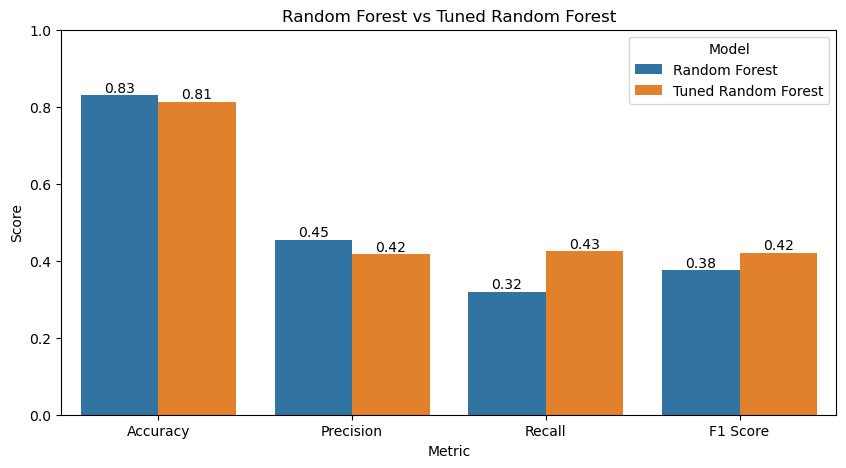

In [75]:
comparison_melted = comparison_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10,5))
ax = sns.barplot(
    data=comparison_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Random Forest vs Tuned Random Forest")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("Metric")
plt.legend(title="Model")
plt.show()

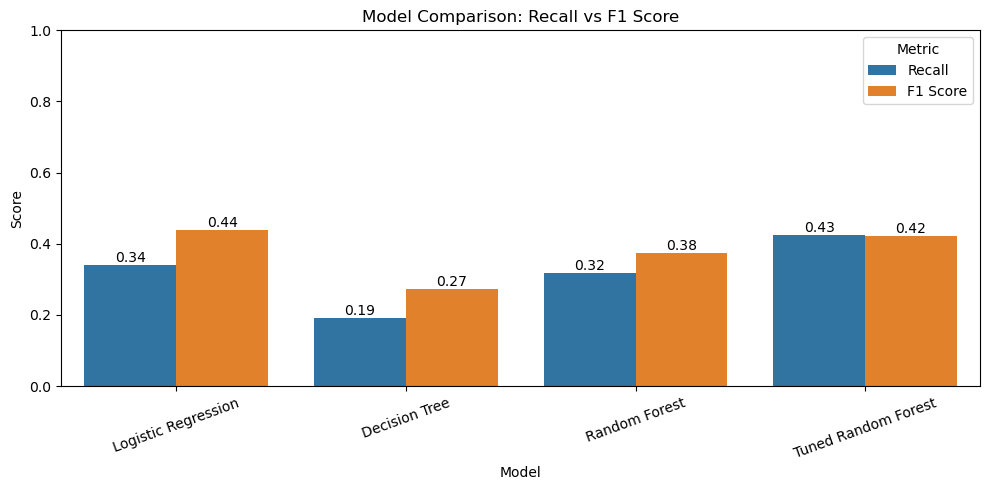

In [77]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Recall": [
        recall_score(y_test, log_preds),
        recall_score(y_test, dectree_preds),
        recall_score(y_test, rfc_preds),
        recall_score(y_test, tuned_rfc_preds)
    ],
    "F1 Score": [
        f1_score(y_test, log_preds),
        f1_score(y_test, dectree_preds),
        f1_score(y_test, rfc_preds),
        f1_score(y_test, tuned_rfc_preds)
    ]
})
comparison_melted = comparison_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=comparison_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Model Comparison: Recall vs F1 Score")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

For employee attrition prediction, recall is important because the goal is to identify employees who may leave. 
F1 score is also considered because it balances recall and precision. 
Based on the comparison, the final selected model is Tuned Random Forest Model.

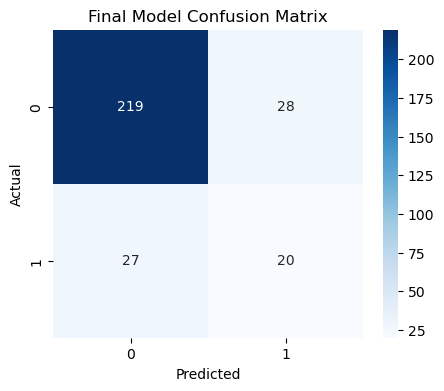

In [80]:
final_preds = tuned_rfc_preds

cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

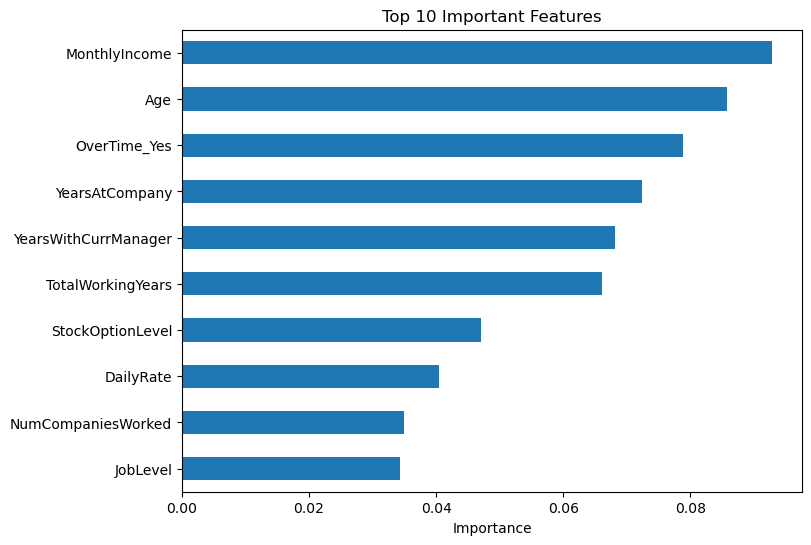

In [82]:
final_model = grid_search.best_estimator_.named_steps["model"]

feature_importance = pd.Series(
    final_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,6))
feature_importance.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()

The final model selected was Tuned Random Forest Model. 
The model was evaluated mainly using recall and F1 score because employee attrition is an imbalanced classification problem. 
The most important features influencing attrition included Monthly Income, Age, and Overtime.

In [85]:
import joblib

joblib.dump(grid_search.best_estimator_, "final_attrition_model.pkl")

['final_attrition_model.pkl']

In [87]:
from sklearn.metrics import recall_score, f1_score
import pandas as pd

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Recall": [
        recall_score(y_test, log_preds),
        recall_score(y_test, dectree_preds),
        recall_score(y_test, rfc_preds),
        recall_score(y_test, tuned_rfc_preds)
    ],
    "F1 Score": [
        f1_score(y_test, log_preds),
        f1_score(y_test, dectree_preds),
        f1_score(y_test, rfc_preds),
        f1_score(y_test, tuned_rfc_preds)
    ]
})

model_results

,Model,Recall,F1 Score
0,Logistic Regression,0.340426,0.438356
1,Decision Tree,0.191489,0.272727
2,Random Forest,0.319149,0.375000
3,Tuned Random Forest,0.425532,0.421053


In [89]:
model_results.to_csv("model_results.csv", index=False)